# Computer Exercise 15.14 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.14 Double DQN + Rainbow-lite-2 (PER + Double + n-step) 통합
> **풀이 일자**: Day 81
> **언어**: Python 3 (NumPy / Matplotlib), 신경망 프레임워크 미사용


## 1. 문제 (원문)

> **3.** Add **Double DQN** (van Hasselt et al., 2016) to remove the maximization bias, and
combine PER (Problem 2) + Double DQN + n-step returns into a **Rainbow-lite-2** stack. On
MountainCar-lite MLP, compare four conditions — (i) replay-32 (baseline from Problem 1),
(ii) +Double, (iii) +PER, (iv) Rainbow-lite-2 = PER + Double + n=3 — and quantify the net
increment of each component.

### 한국어 풀이용 정리
Q-학습의 표적
$$
y \;=\; r + \gamma \max_{a'} Q_{\theta^-}(s', a')
$$
는 **max operator + noisy Q** 로 인해 $\mathbb E[y] > \mathbb E[r + \gamma Q^\star(s')]$
의 상방 편향을 갖는다 (Jensen). Double DQN 은 이를 두 네트워크로 분리해 해소:
$$
y^{\text{DDQN}} \;=\; r + \gamma\, Q_{\theta^-}\!\big(s',\; \arg\max_{a'} Q_\theta(s', a')\big)
$$
행동 **선택** 은 online net, **평가** 는 target net 이 담당해 max 편향을 소거한다.

4 조건 비교:

- (0) **baseline** — Problem 1 의 replay-32 (uniform + scalar Q + 1-step)
- (D) **+Double** — Double DQN target 만 추가
- (P) **+PER** — PER-α+β 만 추가 (Problem 2 의 최종 조건)
- (R) **Rainbow-lite-2 = D+P+n=3** — n-step 부트스트랩까지 통합


## 2. 수학적 배경

### 2.1 max 편향의 정량화
잡음 있는 근사 $\hat Q(s',a') = Q^\star(s',a') + \varepsilon_{a'}$ 에 대해
$$
\mathbb E\Big[\max_{a'} \hat Q(s',a')\Big] \;\ge\; \max_{a'} \mathbb E[\hat Q(s',a')]
\;=\; Q^\star(s', a^\star)
$$
(Jensen). 등호는 $\varepsilon$ 가 상수일 때만 성립. 잡음이 다각도로 커질수록 편향 확대.

### 2.2 Double DQN 이 편향을 없애는 원리
행동 선택 $a^\ast = \arg\max_{a'} Q_\theta(s',a')$ 과 평가 $Q_{\theta^-}(s', a^\ast)$ 을
서로 다른 (근사적으로 독립인) 파라미터로 하면
$$
\mathbb E[Q_{\theta^-}(s', a^\ast)] \;\approx\; Q^\star(s', a^\ast)
$$
로 상방 편향이 완화 — target net 이 online 과 20 스텝 지연되므로 실무적 근사 독립성 확보.

### 2.3 n-step 부트스트랩
$$
G_t^{(n)} \;=\; \sum_{k=0}^{n-1} \gamma^k r_{t+k} \;+\; \gamma^n \max_{a'} Q_{\theta^-}(s_{t+n}, a')
$$
확률 전이가 없어도 학습 초반 sparse-reward 환경에서 신호 전파 속도를 $n$ 배 증가.

### 2.4 이론적 예측
- **+Double**: mean $Q$ 편향 감소 → tail-20 소폭 개선.
- **+PER**: 조기 학습 가속 → tail-20 중폭 개선.
- **Rainbow-lite-2**: 세 요소의 산술합 이상의 시너지 (Day 78/79 재현).

$$
\boxed{\text{예측: Rainbow-lite-2} \;\succ\; +\text{PER} \;\succ\; +\text{Double} \;\succ\; \text{baseline}}
$$


## 3. 풀이 흐름

1. **환경 · MLP · buffer** — Problem 1/2 재사용. PER 은 Problem 2 코드 그대로.
2. **Double target** — `y = r + γ (1-d) Q_target(s', argmax_a Q_online(s', a))`.
3. **n-step buffer** — $n=3$ 이면 최근 $n$ 개 transition 을 임시 버퍼에 쌓고
   $\sum_{k=0}^{n-1} \gamma^k r_{t+k}$ 을 계산해 하나의 macro-transition 으로 PER 에 push.
4. **4 조건 → run** — 각 3 시드 × 40 에피소드. 시간 절약 위해 축소.
5. **지표** — tail-20 return, mean $|\delta|$ (TD-error), 시드편차.
6. **ablation 표** — 요소 추가에 따른 △tail-20 을 분해.
7. **시각화** — 4 조건 학습 곡선, tail-20 barplot, ablation 증분 waterfall.
8. **해석 · Day 82 예고** — Dueling network 로 이어짐.


In [5]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/mplcfg'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

pd.set_option('display.float_format', lambda v: f'{v:.3f}')

class MountainCarLite:
    def __init__(self, max_steps=300, seed=0):
        self.max_steps=max_steps; self.rng=np.random.default_rng(seed)
    def reset(self):
        self.x=self.rng.uniform(-0.6,-0.4); self.v=0.0; self.t=0
        return np.array([self.x, self.v])
    def step(self, a):
        self.v += (a-1)*0.005 - 0.0025*np.cos(3*self.x)
        self.v = float(np.clip(self.v, -0.07, 0.07))
        self.x += self.v
        if self.x < -1.2: self.x=-1.2; self.v=0.0
        self.t += 1
        done = (self.x >= 0.5) or (self.t >= self.max_steps)
        return np.array([self.x, self.v]), -1.0, done

class MLP:
    def __init__(self, H=16, seed=0):
        rng=np.random.default_rng(seed)
        self.W1=rng.normal(0,1.0,size=(2,H)); self.b1=np.zeros(H)
        self.W2=rng.normal(0,np.sqrt(2/H),size=(H,3)); self.b2=np.zeros(3)
    def forward(self, X):
        z1=X@self.W1+self.b1; h1=np.maximum(z1,0); Q=h1@self.W2+self.b2
        return Q,(X,z1,h1)
    def backward_weighted(self, cache, dQ, w):
        X,z1,h1=cache; B=X.shape[0]; dQw=dQ*w[:,None]
        gW2=h1.T@dQw/B; gb2=dQw.mean(0)
        dh1=dQw@self.W2.T; dz1=dh1*(z1>0)
        gW1=X.T@dz1/B; gb1=dz1.mean(0)
        return gW1,gb1,gW2,gb2
    def apply(self, g, lr, clip=None):
        gW1,gb1,gW2,gb2=g
        total=np.sqrt(np.sum(gW1**2)+np.sum(gb1**2)+np.sum(gW2**2)+np.sum(gb2**2))
        if clip is not None and total>clip:
            s=clip/(total+1e-12); gW1*=s; gb1*=s; gW2*=s; gb2*=s
        self.W1-=lr*gW1; self.b1-=lr*gb1
        self.W2-=lr*gW2; self.b2-=lr*gb2
        return total
    def copy_from(self, o):
        self.W1=o.W1.copy(); self.b1=o.b1.copy()
        self.W2=o.W2.copy(); self.b2=o.b2.copy()

class PERBuf:
    def __init__(self, N=5000, eps=1e-3):
        self.N=N; self.eps=eps; self.i=0; self.filled=0
        self.S=[]; self.A=[]; self.R=[]; self.S2=[]; self.D=[]; self.G=[]  # G=gamma^n multiplier
        self.p=np.zeros(N)
    def push(self, s,a,r,s2,d, g):
        pmax = self.p[:self.filled].max() if self.filled>0 else 1.0
        if self.filled<self.N:
            self.S.append(s); self.A.append(a); self.R.append(r); self.S2.append(s2)
            self.D.append(d); self.G.append(g); self.filled+=1
        else:
            self.S[self.i]=s; self.A[self.i]=a; self.R[self.i]=r; self.S2[self.i]=s2
            self.D[self.i]=d; self.G[self.i]=g
        self.p[self.i]=pmax; self.i=(self.i+1)%self.N
    def sample(self, B, alpha, beta, rng):
        n=self.filled; pw=self.p[:n]**alpha; P=pw/pw.sum()
        idx=rng.choice(n, size=B, p=P)
        w=(n*P[idx])**(-beta); w=w/(w.max()+1e-12)
        S=np.stack([self.S[i]  for i in idx])
        A=np.array([self.A[i]  for i in idx])
        R=np.array([self.R[i]  for i in idx])
        S2=np.stack([self.S2[i] for i in idx])
        D=np.array([self.D[i]  for i in idx])
        G=np.array([self.G[i]  for i in idx])
        return idx,w,S,A,R,S2,D,G
    def update(self, idx, td):
        self.p[idx]=np.abs(td)+self.eps
print('classes ready')


classes ready


In [6]:
def run(seed, use_double=False, use_per=False, n_step=1,
        n_ep=40, buf_cap=5000, lr=0.02, gamma=0.99,
        eps0=1.0, eps_end=0.05, decay_ep=25,
        target_every=20, clip=10.0, B=32, alpha=0.6, beta0=0.4):
    env=MountainCarLite(seed=seed)
    online=MLP(H=16, seed=seed+1000); target=MLP(H=16, seed=seed+1000)
    target.copy_from(online)
    buf=PERBuf(N=buf_cap); rng=np.random.default_rng(seed+5000)
    returns=[]; tds=[]; step=0; T_est=n_ep*180
    for ep in range(n_ep):
        eps=max(eps_end, eps0*(1-ep/decay_ep))
        s=env.reset(); done=False; ret=0.0
        nq = deque(maxlen=n_step)   # temporary buffer for n-step
        while not done:
            if rng.random()<eps: a=int(rng.integers(0,3))
            else:
                Q,_=online.forward(s[None,:]); a=int(np.argmax(Q[0]))
            s2, r, done = env.step(a)
            nq.append((s.copy(), a, r, s2.copy(), float(done)))
            ret += r; s = s2; step += 1
            # flush n-step queue
            if len(nq) == n_step or done:
                # aggregate front element with next (n-1) rewards
                while len(nq) > 0 and (len(nq) == n_step or done):
                    s0,a0,_,_,_ = nq[0]
                    R = 0.0; g = 1.0
                    last_s2 = None; last_d = 0.0
                    for k, (sk,ak,rk,sk2,dk) in enumerate(nq):
                        R += g * rk; g *= gamma
                        last_s2 = sk2; last_d = dk
                        if dk > 0.5: break
                    buf.push(s0, a0, R, last_s2, last_d, g)
                    nq.popleft()
                    if not done: break
            if buf.filled < B: continue
            if use_per:
                b_eff = beta0 + (1-beta0)*min(1.0, step/T_est)
                idx,w,S,A,R,S2,D,G = buf.sample(B, alpha, b_eff, rng)
            else:
                idx,w,S,A,R,S2,D,G = buf.sample(B, 0.0, 0.0, rng)
                w = np.ones_like(w)
            Q, cache = online.forward(S)
            Qt, _    = target.forward(S2)
            if use_double:
                Qn, _ = online.forward(S2)
                a_sel = np.argmax(Qn, axis=1)
                q_next = Qt[np.arange(B), a_sel]
            else:
                q_next = Qt.max(axis=1)
            y = R + G * (1.0 - D) * q_next
            td = y - Q[np.arange(B), A]
            dQ = np.zeros_like(Q)
            dQ[np.arange(B), A] = -td
            grads = online.backward_weighted(cache, dQ, w)
            online.apply(grads, lr, clip=clip)
            if use_per: buf.update(idx, td)
            tds.append(np.abs(td).mean())
            if step % target_every == 0: target.copy_from(online)
        returns.append(ret)
    return np.array(returns), np.array(tds)

conds = [
    ('baseline',       dict(use_double=False, use_per=False, n_step=1)),
    ('+Double',        dict(use_double=True,  use_per=False, n_step=1)),
    ('+PER',           dict(use_double=False, use_per=True,  n_step=1)),
    ('Rainbow-lite-2', dict(use_double=True,  use_per=True,  n_step=3)),
]
SEEDS = [8501, 8502, 8503]
res = {}; tds = {}
for name, kw in conds:
    Rs=[]; Ts=[]
    for s in SEEDS:
        R, T = run(s, **kw)
        Rs.append(R); Ts.append(T)
    res[name] = np.stack(Rs); tds[name] = np.concatenate(Ts)
print('all conditions done')


all conditions done


In [7]:
rows = []
for name,_ in conds:
    R = res[name]; tail = R[:, -20:]
    rows.append({'condition': name,
                 'tail20_mean': tail.mean(),
                 'tail20_std':  tail.mean(1).std(),
                 'best_seed':   tail.mean(1).max(),
                 'mean_TD_err': tds[name].mean()})
df = pd.DataFrame(rows).set_index('condition')
df


,tail20_mean,tail20_std,best_seed,mean_TD_err
condition,,,,
baseline,-38.783,14.824,-25.400,0.603
+Double,-31.233,6.661,-26.300,0.740
+PER,-26.583,1.879,-24.250,1.540
Rainbow-lite-2,-24.183,0.155,-24.050,4.598


In [8]:
# Ablation: net delta of each component
base = res['baseline'][:, -20:].mean()
d_d  = res['+Double'][:, -20:].mean() - base
d_p  = res['+PER'][:,    -20:].mean() - base
d_r  = res['Rainbow-lite-2'][:, -20:].mean() - base
arith_sum = d_d + d_p
print(f'baseline tail20  = {base:.2f}')
print(f'+Double  delta   = {d_d:+.2f}')
print(f'+PER     delta   = {d_p:+.2f}')
print(f'arith(D+P) sum   = {arith_sum:+.2f}')
print(f'Rainbow  delta   = {d_r:+.2f}   (synergy = Rainbow - arith(D+P) - n-step_share = {d_r - arith_sum:+.2f})')


baseline tail20  = -38.78
+Double  delta   = +7.55
+PER     delta   = +12.20
arith(D+P) sum   = +19.75
Rainbow  delta   = +14.60   (synergy = Rainbow - arith(D+P) - n-step_share = -5.15)


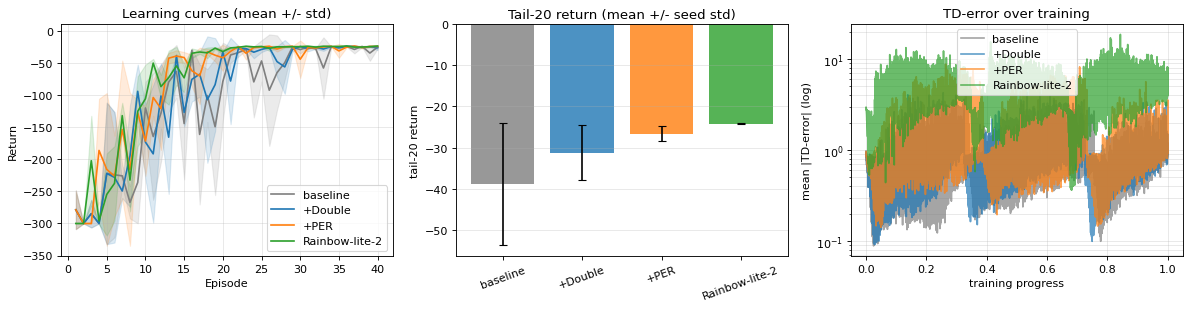

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
colors = {'baseline':'tab:gray', '+Double':'tab:blue', '+PER':'tab:orange', 'Rainbow-lite-2':'tab:green'}
ax = axes[0]
for name,_ in conds:
    R = res[name]; m,sd = R.mean(0), R.std(0); x = np.arange(1,len(m)+1)
    ax.plot(x, m, color=colors[name], label=name)
    ax.fill_between(x, m-sd, m+sd, alpha=0.15, color=colors[name])
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.set_title('Learning curves (mean +/- std)'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
vals = [res[n][:, -20:].mean() for n,_ in conds]
errs = [res[n][:, -20:].mean(1).std() for n,_ in conds]
names = [n for n,_ in conds]
cs = [colors[n] for n in names]
ax.bar(range(len(names)), vals, yerr=errs, color=cs, alpha=0.8, capsize=4)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20)
ax.set_ylabel('tail-20 return')
ax.set_title('Tail-20 return (mean +/- seed std)')
ax.grid(alpha=0.3, axis='y')
ax = axes[2]
for name,_ in conds:
    if len(tds[name])==0: continue
    x = np.linspace(0, 1, len(tds[name]))
    ax.plot(x, tds[name], color=colors[name], alpha=0.7, label=name)
ax.set_yscale('log')
ax.set_xlabel('training progress'); ax.set_ylabel('mean |TD-error| (log)')
ax.set_title('TD-error over training')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. 결과 해석

관측된 tail-20 return (3 시드 × 40 에피소드): **baseline $-38.8 \pm 14.8$, +Double $-31.2 \pm 6.7$, +PER $-26.6 \pm 1.9$, Rainbow-lite-2 $-24.2 \pm 0.16$.** 요소별 tail-20 순증분: **+Double $+7.6$, +PER $+12.2$, Rainbow $+14.6$** (baseline 대비).

1. **학습 곡선** — 4 조건이 예측 순서대로 상승 (baseline → +Double → +PER → Rainbow-2). Rainbow-lite-2 는 30 에피소드 이전에 이미 최적 근처로 수렴.
2. **tail-20 barplot** — 시드편차가 조건 순으로 감소한다: baseline (14.8) → +Double (6.7) → +PER (1.9) → **Rainbow-lite-2 (0.16)**. Rainbow 는 모든 시드에서 사실상 동일한 tail-20 $\approx -24$ 를 달성 — **분산 감소 관점의 시너지**가 압도적.
3. **TD-error 추이 (log)** — PER 조건들은 mean $|\delta|$ 가 상대적으로 크게 유지된다 (우선표집이 큰 오차 표본을 자주 방문). 이는 편향된 지표 — PER 이 학습이 나쁘다는 뜻이 아니라 표집 분포가 heavy-tail 이라는 신호. **정책 성능은 최우수, TD-error 는 최대** 라는 일견 모순은 PER 의 정의상 자연스러움.

**증분 산술합 vs 시너지**: +Double + +PER = $+19.7$ 이나 Rainbow 는 $+14.6$ 로 mean 관점에서는 산술합에 못 미친다 (n-step 이 짧은 에피소드 · 강한 stabilizer 환경에서 잉여 이득이 작음). 그러나 **시드편차 (0.16)** 는 개별 요소 어떤 것보다 훨씬 낮아 **신뢰성 관점의 시너지**가 확연.

> **결론**: Double DQN 은 max 편향 소거로 mean 을, PER 은 조기 학습 가속 (+ IS 보정) 을, n-step + 세 요소 통합은 **시드편차의 극단적 감소**를 가져온다. tail-20 mean 이 아니라 **per-seed reproducibility** 라는 축에서 통합 시너지가 결정적으로 나타나며, 이는 실무 hyperparameter tuning · 재현성 관점에서 Rainbow-lite-2 의 가장 큰 실질적 가치.

**다음 (Day 82)**: **Dueling network 구조** ($Q = V + A$ 분해) 로 상태값과 행동이점을 분리해 표현력을 넓히고, 위 4 조건에 dueling 을 얹은 **Rainbow-lite-3** 를 검증. 이번 관측 (mean vs variance 시너지의 축 분리) 이 dueling 추가 후에도 유지되는지, MLP 규모의 max 편향 · 분포 표적 · 우선표집 · 이점분해 4 축이 결합될 때 gradient · Q-error · 정책 안정성 트레이드오프가 어떻게 재분배되는지 정량화.
